In [1]:
import os
import pandas as pd
import h5py

import matplotlib.pyplot as plt


from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import numpy as np

In [137]:
# Read the data

path = "./data/"
file_template = "muplus45deg10gev_CLD_RECO_REC.edm4hep.hdf5"
file_path = os.path.join(path, file_template)

with h5py.File(file_path, 'r') as hdf_file:
    mcParticle = hdf_file["MCParticles"]
    inTracker = hdf_file["InnerTrackerBarrelCollection"]
    recon = hdf_file["PandoraPFOs"]
    siTrack = hdf_file["SiTracks"]
    siTrackState = hdf_file["_SiTracks_trackStates"]

    # Convert to DataFrame directly (no need for appending)
    df_mc = pd.DataFrame({dataset_name: mcParticle[dataset_name][:] for dataset_name in mcParticle.keys()})
    df_inTrack = pd.DataFrame({dataset_name: inTracker[dataset_name][:] for dataset_name in inTracker.keys()})
    df_recon = pd.DataFrame({dataset_name: recon[dataset_name][:] for dataset_name in recon.keys()})
    df_siTrack = pd.DataFrame({dataset_name: siTrack[dataset_name][:] for dataset_name in siTrack.keys()})
    df_siTrackState = pd.DataFrame({dataset_name: siTrackState[dataset_name][:] for dataset_name in siTrackState.keys()})

# Print the datasets and size
print(f"MCParticles: {df_mc.keys()}, shape: {df_mc.shape}")
print(f"InnerTracker: {df_inTrack.keys()}, shape: {df_inTrack.shape}")
print(f"PandoraPFOs: {df_recon.keys()}, shape: {df_recon.shape}")
print(f"siTrack: {df_siTrack.keys()}, shape: {df_siTrack.shape}")
print(f"siTrackStates: {df_siTrackState.keys()}, shape: {df_siTrackState.shape}")

MCParticles: Index(['PDG', 'charge', 'daughters_begin', 'daughters_end', 'endpoint.x',
       'endpoint.y', 'endpoint.z', 'generatorStatus', 'mass', 'momentum.x',
       'momentum.y', 'momentum.z', 'momentumAtEndpoint.x',
       'momentumAtEndpoint.y', 'momentumAtEndpoint.z', 'parents_begin',
       'parents_end', 'simulatorStatusDG', 'time', 'vertex.x', 'vertex.y',
       'vertex.z'],
      dtype='object'), shape: (1000, 22)
InnerTracker: Index(['cellID', 'eDep', 'momentumX', 'momentumY', 'momentumZ', 'pathLength',
       'positionX', 'positionY', 'positionZ', 'quality', 'time'],
      dtype='object'), shape: (1000, 11)
PandoraPFOs: Index(['PDG', 'charge', 'cluster_begin', 'cluster_end', 'energy', 'mass',
       'momentumX', 'momentumY', 'momentumZ', 'particles_begin',
       'particles_end', 'referencePointX', 'referencePointY',
       'referencePointZ', 'tracks_begin', 'tracks_end'],
      dtype='object'), shape: (1000, 16)
siTrack: Index(['chi2', 'ndf', 'trackStates_begin', 'trackS

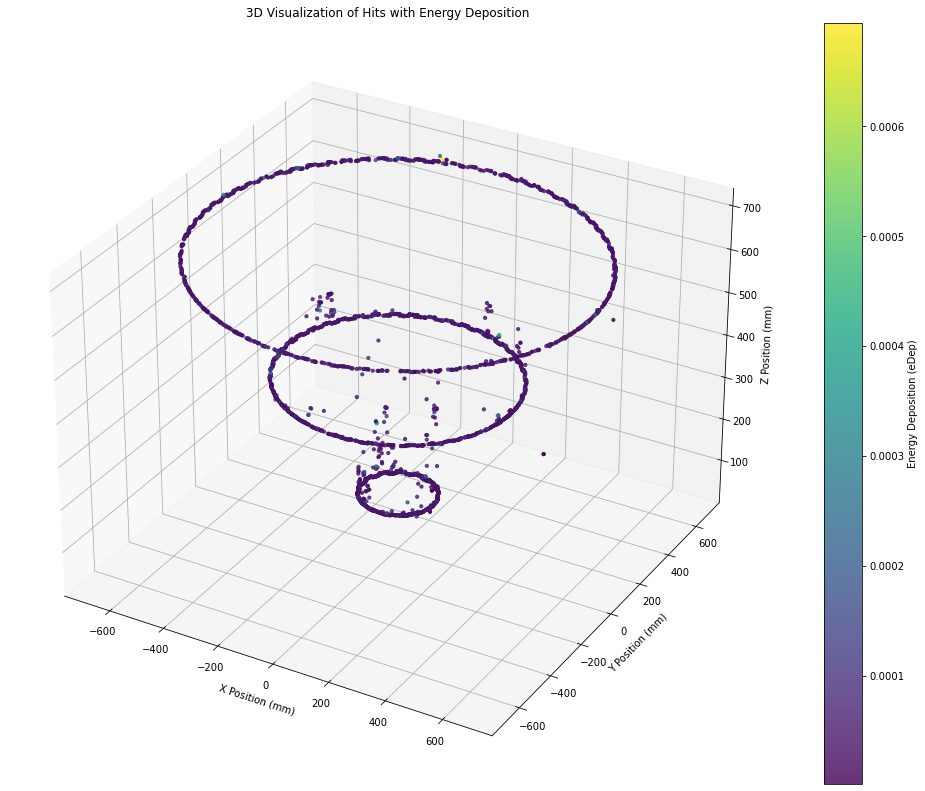

In [138]:
# Extract hit positions and energy deposition
x_positions = np.concatenate(df_inTrack["positionX"])
y_positions = np.concatenate(df_inTrack["positionY"])
z_positions = np.concatenate(df_inTrack["positionZ"])
eDep_values = np.concatenate(df_inTrack["eDep"])

# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 14))
ax = fig.add_subplot(111, projection='3d')

# Use eDep for coloring or sizing
scatter = ax.scatter(x_positions, y_positions, z_positions, c=eDep_values, cmap='viridis', s=10, alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy Deposition (eDep)')

# Add axis labels
ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

plt.title("3D Visualization of Hits with Energy Deposition")
plt.show()

In [139]:
# interactive visualization of the hits

x_positions = np.concatenate(df_inTrack["positionX"])
y_positions = np.concatenate(df_inTrack["positionY"])
z_positions = np.concatenate(df_inTrack["positionZ"])
eDep_values = np.concatenate(df_inTrack["eDep"])

# Create a 3D interactive scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_positions,
    y=y_positions,
    z=z_positions,
    mode='markers',
    marker=dict(
        size=3,
        color=eDep_values,  # color by energy deposition
        colorscale='Viridis',
        colorbar=dict(title='eDep'),
        opacity=0.8
    )
)])

fig.update_layout(
    title=" ",
    scene=dict(
        xaxis_title='X Position (mm)',
        yaxis_title='Y Position (mm)',
        zaxis_title='Z Position (mm)',
    ),
    width=800,
    height=600
)

fig.show()


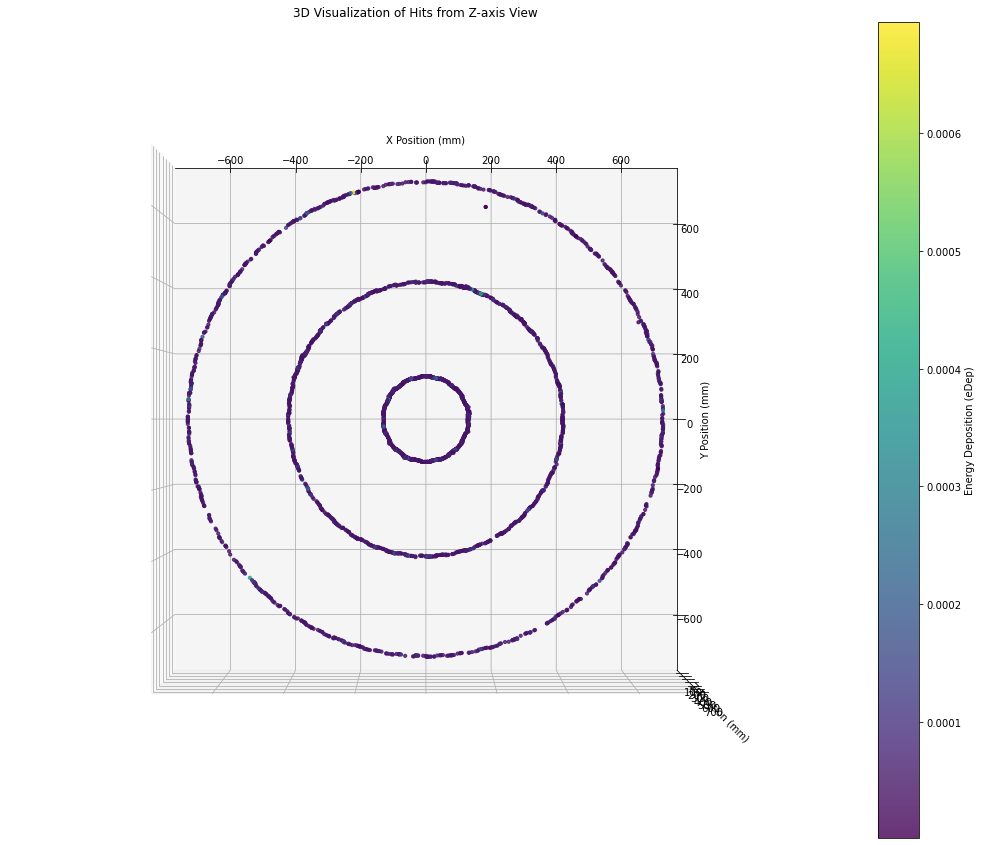

In [140]:
# view along Z axis
x_positions = np.concatenate(df_inTrack["positionX"])
y_positions = np.concatenate(df_inTrack["positionY"])
z_positions = np.concatenate(df_inTrack["positionZ"])
eDep_values = np.concatenate(df_inTrack["eDep"])

# Create a 3D scatter plot
fig = plt.figure(figsize=(20, 15))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot with energy deposition as color
scatter = ax.scatter(x_positions, y_positions, z_positions, c=eDep_values, cmap='viridis', s=10, alpha=0.8)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Energy Deposition (eDep)')

# Set axis labels
ax.set_xlabel("X Position (mm)")
ax.set_ylabel("Y Position (mm)")
ax.set_zlabel("Z Position (mm)")

# Rotate the view to look along the Z-axis
ax.view_init(elev=90, azim=-90)  # Adjust elevation and azimuth for Z-axis view

plt.title("3D Visualization of Hits from Z-axis View")
plt.show()

In [141]:
# Calculate radius for each entry
df_inTrack["radius_l0"] = [np.sqrt(np.array(x)**2 + np.array(y)**2) for x, y in zip(df_inTrack['positionX'], df_inTrack['positionY'])]

## select only the innermost layer and convert to cylindrical coordinate

In [142]:
df_inTrackl0 = []  

for index, row in df_inTrack.iterrows():
    r_val = row["radius_l0"]
    x_val = row["positionX"]
    y_val = row["positionY"]
    z_val = row["positionZ"]
    eDep_val = row["eDep"]
    cellID_val = row["cellID"]
    
    #list to store each row data
    row_data = {
        "positionX": [],
        "positionY": [],
        "positionZ": [],
        "eDep": [],
        "cellID":[],
        "radius": []
    }
    
    
    #filter based on radius threshold
    for r, x, y, z, e, c in zip(r_val, x_val, y_val, z_val, eDep_val, cellID_val):
        if r < 200:
            row_data["positionX"].append(x)
            row_data["positionY"].append(y)
            row_data["positionZ"].append(z)
            row_data["eDep"].append(e)
            row_data["radius"].append(r)
            row_data["cellID"].append(c)
    
    #append to the main list
    df_inTrackl0.append(row_data)
            

#convert filtered values to pandas
df_inTrackl0 = pd.DataFrame(df_inTrackl0)

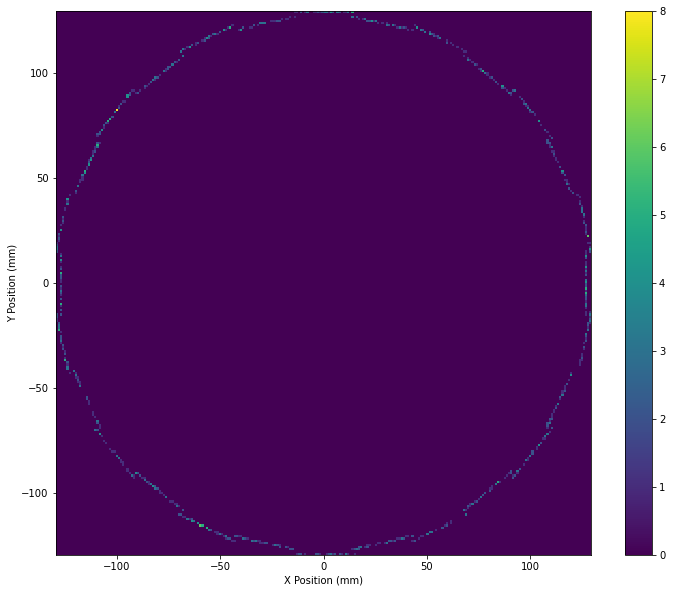

In [143]:
# view along Z axis (Innermost layer)
x_positions = np.concatenate(df_inTrackl0["positionX"])
y_positions = np.concatenate(df_inTrackl0["positionY"])

plt.figure(figsize=(12, 10))
plt.hist2d(x_positions, y_positions, bins=250, cmap='viridis')
plt.colorbar(label=" ")
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.show()

### Sensor Positions of Innermost Layer

In [144]:
# Add 'phi' column to the DataFrame
df_inTrackl0['phi'] = df_inTrackl0.apply(
    lambda row: [np.arctan2(y, x) for x, y in zip(row['positionX'], row['positionY'])],
    axis=1
)

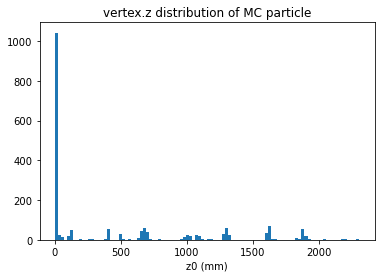

In [145]:
z_dist = np.concatenate(df_mc["vertex.z"])
plt.hist(z_dist,bins=100)
plt.title("vertex.z distribution of MC particle")
plt.xlabel("z0 (mm)")
#plt.xlim(-100,100)
plt.show()

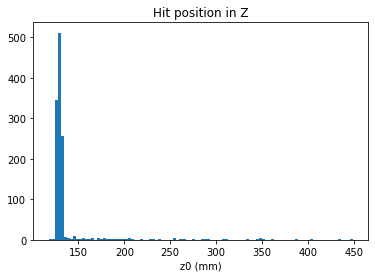

In [146]:
z_dist = np.concatenate(df_inTrackl0["positionZ"])
plt.hist(z_dist,bins=100)
plt.title("Hit position in Z")
plt.xlabel("z0 (mm)")
#plt.xlim(-100,100)
plt.show()

### Filter muon tracks

In [147]:
def filter_muons(df_mc):
    """
    Filters only muon (PDG = ±13) tracks from MCParticle dataset.
    """
    muons = []
    
    for idx, row in df_mc.iterrows():
        pdg = np.array(row["PDG"])
        charge = np.array(row["charge"])
        gen_status = np.array(row["generatorStatus"])
        
        # Select only muons (PDG = ±13)
        #muon_mask = (np.abs(pdg) == 13)& (gen_status == 3)  
        muon_mask = np.abs(pdg) == 13
        
        if np.any(muon_mask):
            muons.append({
                "PDG": pdg[muon_mask],
                "charge": charge[muon_mask],
                "x0": np.array(row["vertex.x"])[muon_mask],
                "y0": np.array(row["vertex.y"])[muon_mask],
                "z0": np.array(row["vertex.z"])[muon_mask],
                "px": np.array(row["momentum.x"])[muon_mask],
                "py": np.array(row["momentum.y"])[muon_mask],
                "pz": np.array(row["momentum.z"])[muon_mask],
                "mass": np.array(row["mass"])[muon_mask],
                "genStatus": np.array(row["generatorStatus"])[muon_mask]
            })
    
    return pd.DataFrame(muons)

# Apply the function
df_mcMuons = filter_muons(df_mc)

In [148]:
def compute_track_parameters(df_mcMuons):
    
    pT_list, theta_list, phi_list, tan_lambda_list = [], [], [], []

    # Iterate through each row
    for _, row in df_mcMuons.iterrows():
        px, py, pz = np.array(row["px"]), np.array(row["py"]), np.array(row["pz"])
        
        # Compute pT, theta, phi, and tan_lambda
        pT = np.sqrt(px**2 + py**2)
        theta = np.arctan2(pT, pz)
        phi = np.arctan2(py, px)
        tan_lambda = pz / pT

        # Append results
        pT_list.append(pT.tolist())
        theta_list.append(theta.tolist())
        phi_list.append(phi.tolist())
        tan_lambda_list.append(tan_lambda.tolist())

    # update the dataframe with new columns
    df_mcMuons["pT"] = pT_list
    df_mcMuons["theta"] = theta_list
    df_mcMuons["phi"] = phi_list
    df_mcMuons["tan_lambda"] = tan_lambda_list

    return df_mcMuons  # Returns updated DataFrame

# **Run function to update df_mcMuons**
df_mcMuons = compute_track_parameters(df_mcMuons)

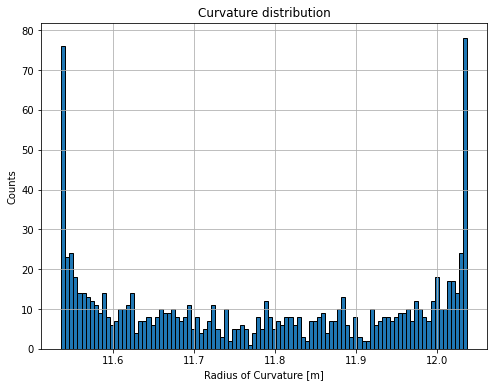

In [149]:
B = 2  # Tesla
radius = df_mcMuons["pT"].apply(lambda r: np.array(r) / (0.3 * B))

# Flatten all arrays in 'radius' into a single array
radius_values = np.concatenate(radius.values)

# Plotting the histogram of radius values
plt.figure(figsize=(8, 6))
plt.hist(radius_values, bins=100, edgecolor='black')
plt.xlabel("Radius of Curvature [m]")
plt.ylabel("Counts")
plt.title("Curvature distribution")
plt.grid(True)
plt.show()

### MC Particle interaction in the sensors

In [150]:
B = 2  # inner_field (Solenoid Field) in hepSim website

def compute_track_intersections(df_mcMuons, df_inTrackl0):
    intersections = []

    
    for hit_index, hit_row in df_inTrackl0.iterrows():
        x_hit_values = np.array(hit_row["positionX"])
        y_hit_values = np.array(hit_row["positionY"])
        z_hit_values = np.array(hit_row["positionZ"])
        
        #added later tupen
        cellID_hit_values = np.array(hit_row["cellID"])
            
        for i in range(len(x_hit_values)):
            x_hit = x_hit_values[i]
            y_hit = y_hit_values[i]
            z_hit = z_hit_values[i]
            
            cellID_hit = cellID_hit_values[i]


            dist = -1.
            
            for track_index, track_row in df_mcMuons.iterrows():
                x0_values = np.array(track_row["x0"])
                y0_values = np.array(track_row["y0"])
                z0_values = np.array(track_row["z0"])
                pT_values = np.array(track_row["pT"]) 
                phi0_values = np.array(track_row["phi"])
                charge_values = np.array(track_row["charge"])
                theta_values = np.array(track_row["theta"])
                tan_lambda_values = np.array(track_row["tan_lambda"]) 
                lambda_angle_values = np.arctan(tan_lambda_values)

                R_values = np.array(pT_values/0.3*B)  #  R = pT/(0.3qB)
                
                for muon_index in range(len(x0_values)):
                    charge = charge_values[muon_index]
                    x0 = x0_values[muon_index]
                    z0 = z0_values[muon_index]    
                    y0 = y0_values[muon_index]
                    pT = pT_values[muon_index]
                    phi0 = phi0_values[muon_index]
                    tan_lambda = tan_lambda_values[muon_index]
                    lambda_angle = lambda_angle_values[muon_index]
                    theta_angle = theta_values[muon_index]
                    R = R_values[muon_index]*1000 ##mm

                    
                    psi = (z_hit - z0)* charge* np.tan(theta_angle)/R
                    
                    x_intersect = x0 + R*np.sin(psi + phi0) - R*np.sin(phi0)
                    y_intersect = y0 + R*np.cos(psi + phi0) - R*np.cos(phi0)
                    z_intersect = z0 + (R * psi)/(np.tan(theta_angle))
                    
                    resid = np.sqrt((x_intersect-x_hit)**2 + (y_intersect-y_hit)**2 + (z_intersect-z_hit)**2 )

                    if (dist < 0 ) or resid < dist: 
                        dist = resid
                        min_track_index = track_index
                        min_x_intersect = x_intersect
                        min_y_intersect = y_intersect
                        min_z_intersect = z_intersect
                        pT_value = pT
                        phi0_value = phi0
                        cellID_min = cellID_hit
                
            # Store with proper indexing information
            if dist >= 0:
                intersections.append({
                    "hit_index": hit_index,
                    "sensor_hit_index": i,
                    "track_index": min_track_index,
                    "x_intersect": min_x_intersect,
                    "y_intersect": min_y_intersect,
                    "z_intersect": min_z_intersect,
                    "x_hit": x_hit,
                    "y_hit": y_hit,
                    "z_hit": z_hit,
                    "pT": pT_value,
                    "phi0": phi0_value,
                    "cellID": cellID_min,
                    "distance": dist
                })
    
    return pd.DataFrame(intersections)

# # Run function
df_track_intersections = compute_track_intersections(df_mcMuons, df_inTrackl0)

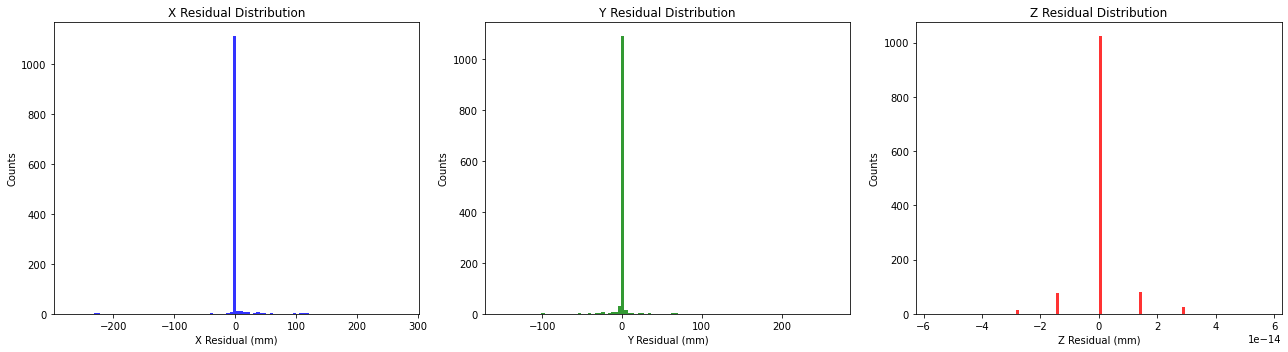

In [151]:
# Flatten residual arrays
x_residuals = df_track_intersections["x_hit"] - df_track_intersections["x_intersect"]
y_residuals = df_track_intersections["y_hit"] - df_track_intersections["y_intersect"]
z_residuals = df_track_intersections["z_hit"] - df_track_intersections["z_intersect"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X residuals
axes[0].hist(x_residuals, bins=100, alpha=0.8, color='blue')
axes[0].set_title('X Residual Distribution')
axes[0].set_xlabel('X Residual (mm)')
axes[0].set_ylabel('Counts')

# Y residuals
axes[1].hist(y_residuals, bins=100, alpha=0.8, color='green')
axes[1].set_title('Y Residual Distribution')
axes[1].set_xlabel('Y Residual (mm)')
axes[1].set_ylabel('Counts')

# Z residuals
axes[2].hist(z_residuals, bins=100, alpha=0.8, color='red')
axes[2].set_title('Z Residual Distribution')
axes[2].set_xlabel('Z Residual (mm)')
axes[2].set_ylabel('Counts')

plt.tight_layout()
#plt.savefig("./plots/residual_genStat_1.png")
plt.show()


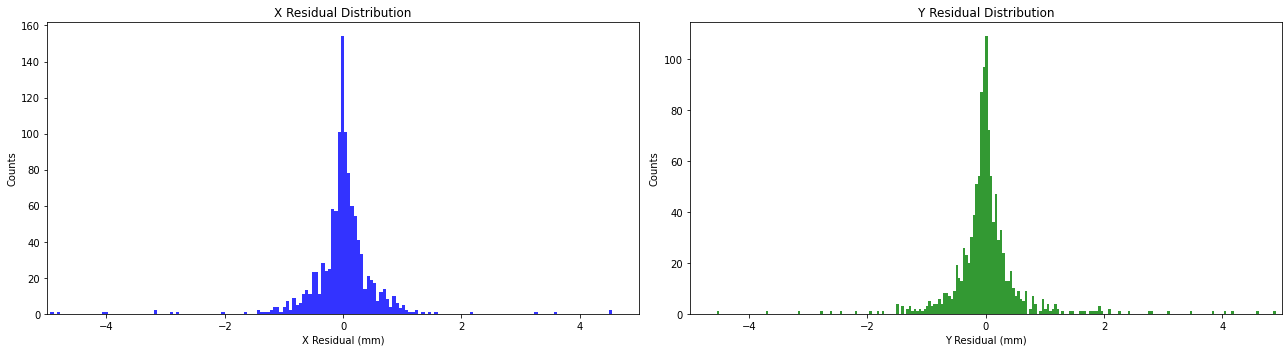

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# X residuals
axes[0].hist(x_residuals, bins=10000, alpha=0.8, color='blue')
axes[0].set_title('X Residual Distribution')
axes[0].set_xlabel('X Residual (mm)')
axes[0].set_ylabel('Counts')
axes[0].set_xlim(-5, 5)  # 

# Y residuals
axes[1].hist(y_residuals, bins=10000, alpha=0.8, color='green')
axes[1].set_title('Y Residual Distribution')
axes[1].set_xlabel('Y Residual (mm)')
axes[1].set_ylabel('Counts')
axes[1].set_xlim(-5,5)  # 

plt.tight_layout()
#plt.savefig("residual_10geV.png")
plt.show()

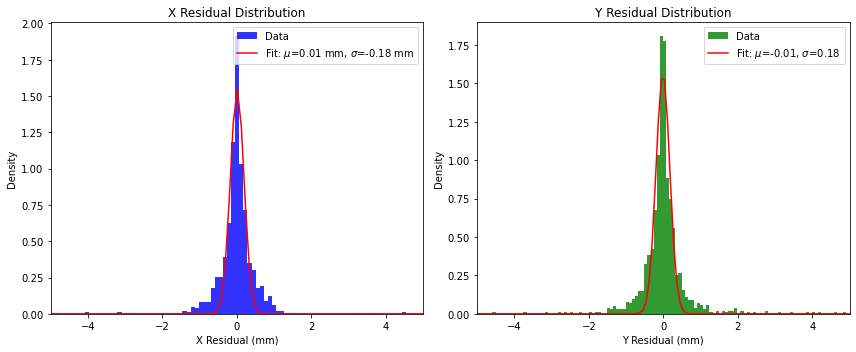

In [153]:
# fit to the residuals

from scipy.optimize import curve_fit

# Define Gaussian function
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# Fit Gaussian to histogram data
def fit_gaussian(data, bins=5000):
    hist, bin_edges = np.histogram(data, bins=bins, density=True)  # Get histogram
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Compute bin centers

    # Initial guess for fitting [Amplitude, Mean, Sigma]
    p0 = [max(hist), np.mean(data), np.std(data)] 

    # Fit Gaussian
    popt, _ = curve_fit(gaussian, bin_centers, hist, p0=p0)

    return popt, bin_centers, hist

# Fit X and Y residuals
popt_x, x_bin_centers, x_hist = fit_gaussian(x_residuals)
popt_y, y_bin_centers, y_hist = fit_gaussian(y_residuals)

# Plot residual distributions with Gaussian fits
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# X residuals
axes[0].hist(x_residuals, bins=5000, alpha=0.8, color='blue', density=True, label="Data")
axes[0].plot(x_bin_centers, gaussian(x_bin_centers, *popt_x), 'r-', label=f'Fit: $\mu$={popt_x[1]:.2f} mm, $\sigma$={popt_x[2]:.2f} mm')
axes[0].set_title('X Residual Distribution')
axes[0].set_xlabel('X Residual (mm)')
axes[0].set_ylabel('Density')
axes[0].set_xlim(-5, 5)
axes[0].legend(loc='upper right')

# Y residuals
axes[1].hist(y_residuals, bins=5000, alpha=0.8, color='green', density=True, label="Data")
axes[1].plot(y_bin_centers, gaussian(y_bin_centers, *popt_y), 'r-', label=f'Fit: $\mu$={popt_y[1]:.2f}, $\sigma$={popt_y[2]:.2f}')
axes[1].set_title('Y Residual Distribution')
axes[1].set_xlabel('Y Residual (mm)')
axes[1].set_ylabel('Density')
axes[1].set_xlim(-5, 5)
axes[1].legend(loc='upper right')

plt.tight_layout()
#plt.savefig("./plots/fitted_residual_10gev.png")
plt.show()

In [155]:
pT = df_track_intersections["pT"]
phi0 = df_track_intersections["phi0"]
x_hit = df_track_intersections["x_hit"]
y_hit = df_track_intersections["y_hit"]
z_hit = df_track_intersections["z_hit"]

#### Dependency with x_hit, y_hit, z_hit?

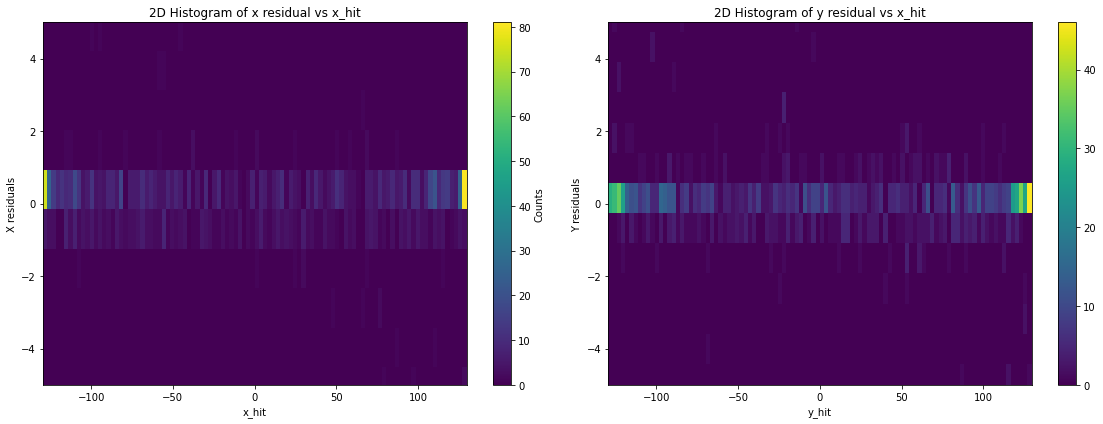

In [156]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: x residual vs pT
h1 = axs[0].hist2d(x_hit, x_residuals, bins = [100,500], cmap='viridis')
axs[0].set_xlabel('x_hit')
axs[0].set_ylabel('X residuals')
axs[0].set_title('2D Histogram of x residual vs x_hit')
axs[0].set_ylim(-5,5)
plt.colorbar(h1[3], ax=axs[0], label='Counts')

# Second plot: y residual vs pT
h2 = axs[1].hist2d(y_hit, y_residuals, bins= [100,500], cmap='viridis')
axs[1].set_xlabel('y_hit')
axs[1].set_ylabel('Y residuals')
axs[1].set_title('2D Histogram of y residual vs x_hit')
axs[1].set_ylim(-5,5)
plt.colorbar(h2[3], ax=axs[1])

plt.tight_layout()
#plt.savefig("plots/residual_hit_10gev.png")
plt.show()

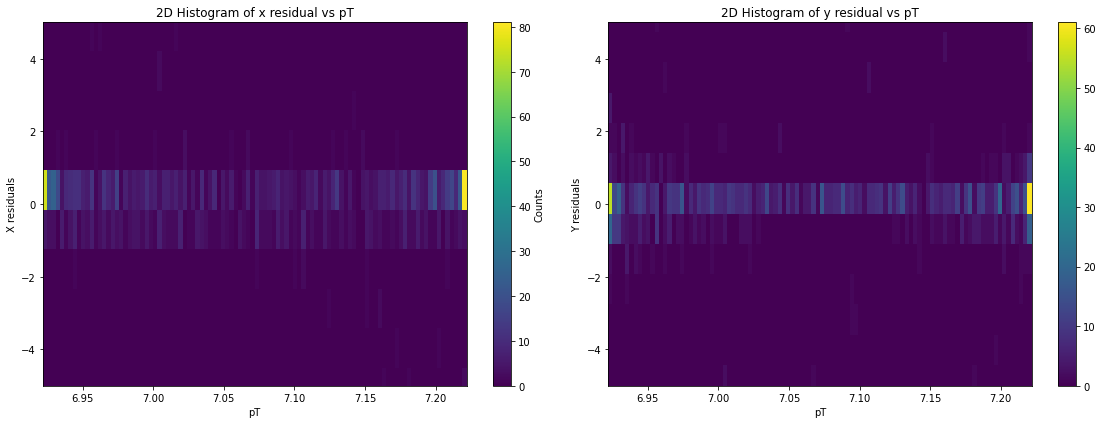

In [157]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: x residual vs pT
h1 = axs[0].hist2d(pT, x_residuals, bins = [100,500], cmap='viridis')
axs[0].set_xlabel('pT')
axs[0].set_ylabel('X residuals')
axs[0].set_title('2D Histogram of x residual vs pT')
axs[0].set_ylim(-5,5)
plt.colorbar(h1[3], ax=axs[0], label='Counts')

# Second plot: y residual vs pT
h2 = axs[1].hist2d(pT, y_residuals, bins=[100,500], cmap='viridis')
axs[1].set_xlabel('pT')
axs[1].set_ylabel('Y residuals')
axs[1].set_title('2D Histogram of y residual vs pT')
axs[1].set_ylim(-5,5)
plt.colorbar(h2[3], ax=axs[1])

plt.tight_layout()
#plt.savefig("plots/residual_vs_pT_10gev.png")
plt.show()

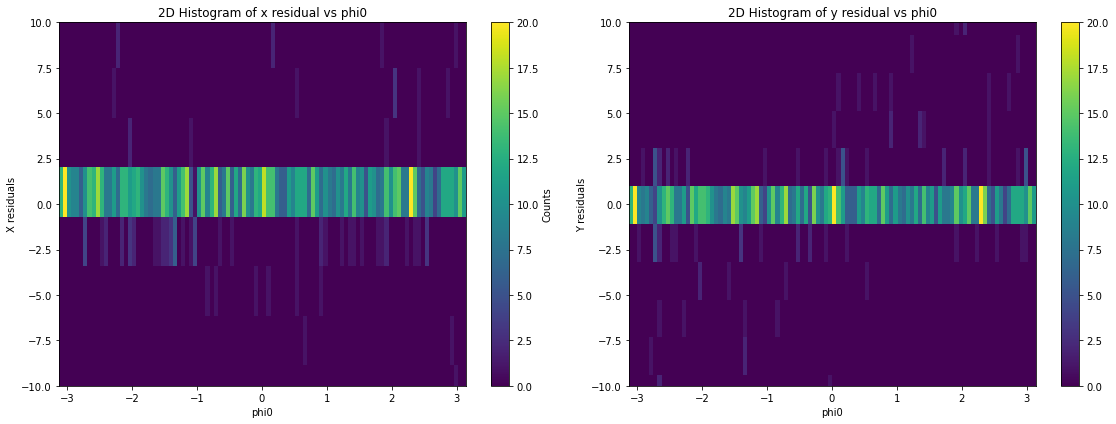

In [158]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# First plot: x residual vs pT
h1 = axs[0].hist2d(phi0, x_residuals, bins=[100,200], cmap='viridis')
axs[0].set_xlabel('phi0')
axs[0].set_ylabel('X residuals')
axs[0].set_title('2D Histogram of x residual vs phi0')
axs[0].set_ylim(-10,10)
plt.colorbar(h1[3], ax=axs[0], label='Counts')

# Second plot: y residual vs pT
h2 = axs[1].hist2d(phi0, y_residuals, bins=[100,200], cmap='viridis')
axs[1].set_xlabel('phi0')
axs[1].set_ylabel('Y residuals')
axs[1].set_title('2D Histogram of y residual vs phi0')
axs[1].set_ylim(-10,10)
plt.colorbar(h2[3], ax=axs[1])

plt.tight_layout()
#plt.savefig("plots/residual_vs_phi0_10gev.png")
plt.show()

In [159]:
## open the sensor position files

file = '../sensor_position_L0.csv'
df_sensor = pd.read_csv(file)

In [160]:
df_sensor.head()

,Sensor,x (cm),y (cm),z (cm)
0,0,12.7,0.0,-46.655
1,1,12.7,0.0,-43.645
2,2,12.7,0.0,-40.635
3,3,12.7,0.0,-37.625
4,4,12.7,0.0,-34.615


In [161]:
# add positions in mm too

df_sensor['x_mm'] = df_sensor['x (cm)'] * 10
df_sensor['y_mm'] = df_sensor['y (cm)'] * 10
df_sensor['z_mm'] = df_sensor['z (cm)'] * 10

In [163]:
df_sensor.head()

,Sensor,x (cm),y (cm),z (cm),x_mm,y_mm,z_mm
0,0,12.7,0.0,-46.655,127.0,0.0,-466.55
1,1,12.7,0.0,-43.645,127.0,0.0,-436.45
2,2,12.7,0.0,-40.635,127.0,0.0,-406.35
3,3,12.7,0.0,-37.625,127.0,0.0,-376.25
4,4,12.7,0.0,-34.615,127.0,0.0,-346.15


## visualize sensor positions

In [169]:
#visualize sensor positions

fig = go.Figure(data=go.Scatter3d(
    x=df_sensor['x_mm'],
    y=df_sensor['y_mm'],
    z=df_sensor['z_mm'],
    mode='markers',
    marker=dict(
        size=3,
        color=df_sensor['z_mm'],  # color by z-position
        colorscale='Viridis',
        opacity=0.8
    ),
    text=[f"Sensor ID: {sid}" for sid in df_sensor["Sensor"]]
))

fig.update_layout(
    title="Interactive 3D Sensor Layout",
    scene=dict(
        xaxis_title='X (mm)',
        yaxis_title='Y (mm)',
        zaxis_title='Z (mm)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [170]:
df_track_intersections.head(10)

,hit_index,sensor_hit_index,track_index,x_intersect,y_intersect,z_intersect,x_hit,y_hit,z_hit,pT,phi0,cellID,distance
0,0,0,315,-124.005344,38.395195,132.488617,-124.052567,38.316341,132.488617,6.928290,-2.842734,335650819,0.091912
1,1,0,875,-109.611564,64.789935,129.695312,-110.099586,64.008385,129.695312,6.942005,-2.609128,335642627,0.921405
2,2,0,780,-17.598384,126.188840,127.816147,-18.251888,126.067856,127.816147,7.048605,-1.710719,335609859,0.664609
3,3,0,130,94.122275,-89.707851,128.062073,93.959656,-89.829666,128.062073,7.179455,0.760031,335749123,0.203185
4,4,0,442,127.701829,21.746546,126.874275,127.659271,22.514332,126.874275,7.219651,-0.170019,335552515,0.768964
5,5,0,173,-54.442160,117.440323,130.636185,-54.987816,117.218460,130.636185,7.006629,-2.006266,335618051,0.589036
6,6,0,668,-49.087644,120.135592,130.853912,-48.465469,120.359451,130.853912,7.012895,-1.960084,335618051,0.661222
7,7,0,852,-50.741057,-119.250933,130.701920,-50.313606,-119.469437,130.701920,7.011305,1.971703,335699971,0.480061
8,8,0,178,-100.733242,81.272592,131.609207,-100.599503,81.503563,131.609207,6.954048,-2.464109,335634435,0.266897
9,9,0,697,127.083865,25.023557,126.871201,127.135719,24.808161,126.871201,7.218926,-0.195764,335552515,0.221550


### Associate sensor with the hits

In [171]:
# constants
sensor_half_size = 15.05  # sensor dimention 30.1 mm by 30.1mm
z_tolerance = 15.05       # tolerable z

# Function to find closest matching sensor and all candidates
def find_best_sensor_with_candidates(row, df_sensor):
    
    #filter by z 
    candidate_sensors = df_sensor[np.abs(df_sensor["z_mm"] - row["z_hit"]) <= z_tolerance].copy()

    #filter by x and y bounds
    candidate_sensors = candidate_sensors[
        (np.abs(candidate_sensors["x_mm"] - row["x_hit"]) <= sensor_half_size) &
        (np.abs(candidate_sensors["y_mm"] - row["y_hit"]) <= sensor_half_size)
    ]

    if candidate_sensors.empty:
        return pd.Series({
            "matched_sensor_id": np.nan,
            "sensor_x_mm": np.nan,
            "sensor_y_mm": np.nan,
            "sensor_z_mm": np.nan,
            "candidate_sensor_ids": []
        })

    # Step 3: find the closest sensor
    candidate_sensors["distance"] = np.sqrt(
        (candidate_sensors["x_mm"] - row["x_hit"])**2 +
        (candidate_sensors["y_mm"] - row["y_hit"])**2 +
        (candidate_sensors["z_mm"] - row["z_hit"])**2
    )

    closest = candidate_sensors.loc[candidate_sensors["distance"].idxmin()]

    return pd.Series({
        "matched_sensor_id": closest["Sensor"],
        "sensor_x_mm": closest["x_mm"],
        "sensor_y_mm": closest["y_mm"],
        "sensor_z_mm": closest["z_mm"],
        "candidate_sensor_ids": candidate_sensors["Sensor"].tolist()
    })

# Apply the function
df_result = df_track_intersections.copy()
df_result[["matched_sensor_id", "sensor_x_mm", "sensor_y_mm", "sensor_z_mm", "candidate_sensor_ids"]] = df_result.apply(
    lambda row: find_best_sensor_with_candidates(row, df_sensor), axis=1
)

In [172]:
#drop rows with NaN values if any 

nan_count = df_result[["matched_sensor_id", "sensor_x_mm", "sensor_y_mm", "sensor_z_mm"]].isna().any(axis=1).sum()
print(f"Number of rows with NaN in pixel index columns: {nan_count}")


df_result = df_result.dropna(subset=["matched_sensor_id", "sensor_x_mm", "sensor_y_mm", "sensor_z_mm"]).copy()

Number of rows with NaN in pixel index columns: 0


## converting hit position and likely interaction of MC particle in the sensor (row,column)

In [173]:
# Constants
pixel_size_mm = 0.025       # 25 microns
sensor_half_size = 15.05     # mm (sensor is 30 mm × 30 mm)

# Function to compute hit and expected (row, column) in the matched sensor
def compute_pixel_positions(row):
    if pd.isna(row["sensor_x_mm"]) or pd.isna(row["x_hit"]) or pd.isna(row["x_intersect"]):
        return pd.Series({
            "hit_row": np.nan,
            "hit_col": np.nan,
            "expected_row": np.nan,
            "expected_col": np.nan
        })

    # Bottom-left corner of the sensor
    sensor_x0 = row["sensor_x_mm"] - sensor_half_size
    sensor_y0 = row["sensor_y_mm"] - sensor_half_size

    # Compute offset in mm
    dx_hit = row["x_hit"] - sensor_x0
    dy_hit = row["y_hit"] - sensor_y0
    dx_pred = row["x_intersect"] - sensor_x0
    dy_pred = row["y_intersect"] - sensor_y0

    # Convert to pixel indices
    hit_col = int(dx_hit / pixel_size_mm)
    hit_row = int(dy_hit / pixel_size_mm)
    expected_col = dx_pred / pixel_size_mm
    expected_row = dy_pred / pixel_size_mm

    return pd.Series({
        "hit_row": hit_row,
        "hit_col": hit_col,
        "expected_row": expected_row,
        "expected_col": expected_col
    })

# Apply it to your result DataFrame
df_result[["hit_row", "hit_col", "expected_row", "expected_col"]] = df_result.apply(
    compute_pixel_positions, axis=1
)

In [174]:
df_result[:10]

,hit_index,sensor_hit_index,track_index,x_intersect,y_intersect,z_intersect,x_hit,y_hit,z_hit,pT,...,distance,matched_sensor_id,sensor_x_mm,sensor_y_mm,sensor_z_mm,candidate_sensor_ids,hit_row,hit_col,expected_row,expected_col
0,0,0,315,-124.005344,38.395195,132.488617,-124.052567,38.316341,132.488617,6.928290,...,0.091912,436.0,-126.253165,28.816461,135.45,[436],981.0,690.0,985.149370,691.912807
1,1,0,875,-109.611564,64.789935,129.695312,-110.099586,64.008385,129.695312,6.942005,...,0.921405,404.0,-114.423046,55.103235,135.45,[404],958.0,774.0,989.467997,794.459289
2,2,0,780,-17.598384,126.188840,127.816147,-18.251888,126.067856,127.816147,7.048605,...,0.664609,276.0,-28.260159,123.815845,135.45,[276],692.0,1002.0,696.919793,1028.470998
3,3,0,130,94.122275,-89.707851,128.062073,93.959656,-89.829666,128.062073,7.179455,...,0.203185,820.0,101.247177,-80.741929,135.45,"[788, 820]",238.0,310.0,243.363147,317.003935
4,4,0,442,127.701829,21.746546,126.874275,127.659271,22.514332,126.874275,7.219651,...,0.768964,52.0,126.253165,28.816461,135.45,[52],349.0,658.0,319.203414,659.946568
5,5,0,173,-54.442160,117.440323,130.636185,-54.987816,117.218460,130.636185,7.006629,...,0.589036,308.0,-56.187944,116.675468,135.45,[308],623.0,650.0,632.594199,671.831377
6,6,0,668,-49.087644,120.135592,130.853912,-48.465469,120.359451,130.853912,7.012895,...,0.661222,308.0,-56.187944,116.675468,135.45,[308],749.0,910.0,740.404936,886.011990
7,7,0,852,-50.741057,-119.250933,130.701920,-50.313606,-119.469437,130.701920,7.011305,...,0.480061,628.0,-56.187944,-116.675468,135.45,[628],490.0,836.0,498.981422,819.875475
8,8,0,178,-100.733242,81.272592,131.609207,-100.599503,81.503563,131.609207,6.954048,...,0.266897,372.0,-101.247177,80.741929,135.45,[372],632.0,627.0,623.226487,622.557397
9,9,0,697,127.083865,25.023557,126.871201,127.135719,24.808161,126.871201,7.218926,...,0.221550,52.0,126.253165,28.816461,135.45,[52],441.0,637.0,450.283860,635.228009


In [176]:
# save the data

df_result.to_csv("df_result.csv", index=False)